In [48]:
# !pip install pyspark
# !pip install -U -q Pydrive
# !apt install openjdk-8-jdk-headless -qq
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

In [49]:
!java --version

openjdk 17.0.19 2026-04-21
OpenJDK Runtime Environment (build 17.0.19+10-1-22.04.2-Ubuntu)
OpenJDK 64-Bit Server VM (build 17.0.19+10-1-22.04.2-Ubuntu, mixed mode, sharing)


# Creating a Pipeline for Machine Learning Model

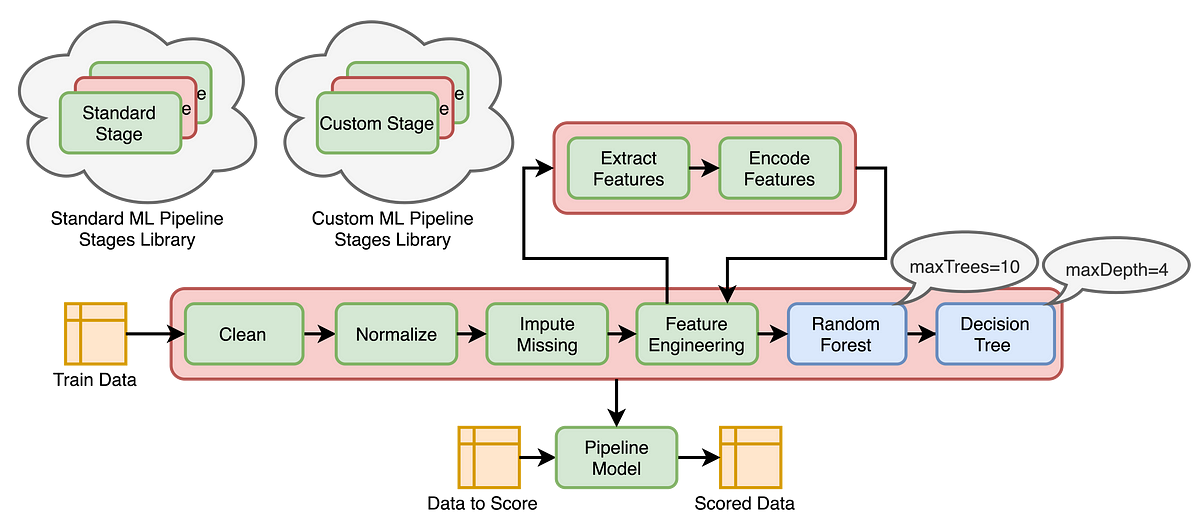

In [50]:
import pyspark
from pyspark.sql import *
from pyspark.sql.functions import *
from pyspark.sql.types import DoubleType
from pyspark import SparkContext, SparkConf
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator,MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
import matplotlib.pyplot as plt

In [51]:
conf = SparkConf()
conf.setAppName("AdultDatasetRandomForest")
conf.setMaster('local[*]')
conf.set("spark.driver.memory", "2G")
conf.set("spark.driver.maxResultSize", "2g")
conf.set("spark.executor.memory", "1G")
spark = SparkSession.builder.getOrCreate()

## Step 1 Load the dataset
Because the dataset does not include column names, create a schema to assign column names and datatypes.

In [52]:
!wget -O adult.csv https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data

--2026-06-19 09:45:20--  https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘adult.csv’

adult.csv               [  <=>               ]   3.79M  17.8MB/s    in 0.2s    

2026-06-19 09:45:21 (17.8 MB/s) - ‘adult.csv’ saved [3974305]



In [53]:
schema = """`age` DOUBLE,
`workclass` STRING,
`fnlwgt` DOUBLE,
`education` STRING,
`education_num` DOUBLE,
`marital_status` STRING,
`occupation` STRING,
`relationship` STRING,
`race` STRING,
`sex` STRING,
`capital_gain` DOUBLE,
`capital_loss` DOUBLE,
`hours_per_week` DOUBLE,
`native_country` STRING,
`income` STRING"""

# df = spark.read.csv("adult.csv", schema=schema)
# df.show(n=20)
adult_df = spark.read.format('csv').option("header","true").schema(schema).load("adult.csv")
# adult_df.show(5)

In [56]:
adult_df

DataFrame[age: double, workclass: string, fnlwgt: double, education: string, education_num: double, marital_status: string, occupation: string, relationship: string, race: string, sex: string, capital_gain: double, capital_loss: double, hours_per_week: double, native_country: string, income: string]

## Basic Statistics
Get basic statistics for numerical columns and a summary for all columns.

In [57]:
# Summary statistics for all columns
adult_df.summary().show()

DataFrame[summary: string, age: string, workclass: string, fnlwgt: string, education: string, education_num: string, marital_status: string, occupation: string, relationship: string, race: string, sex: string, capital_gain: string, capital_loss: string, hours_per_week: string, native_country: string, income: string]

In [24]:
categorical_columns = ["workclass", "education", "marital_status", "occupation",
                       "relationship", "race", "sex", "native_country", "income"]

for column in categorical_columns:
    print(f"Count of distinct values for {column}:")
    adult_df.groupBy(column).count().show()

Count of distinct values for workclass:
+-----------------+-----+
|        workclass|count|
+-----------------+-----+
|        State-gov| 1297|
|      Federal-gov|  960|
| Self-emp-not-inc| 2541|
|        Local-gov| 2093|
|          Private|22696|
|                ?| 1836|
|     Self-emp-inc| 1116|
|      Without-pay|   14|
|     Never-worked|    7|
+-----------------+-----+

Count of distinct values for education:
+-------------+-----+
|    education|count|
+-------------+-----+
|  Prof-school|  576|
|         10th|  933|
|      7th-8th|  646|
|      5th-6th|  333|
|   Assoc-acdm| 1067|
|    Assoc-voc| 1382|
|      Masters| 1723|
|         12th|  433|
|    Preschool|   51|
|          9th|  514|
|    Bachelors| 5354|
|    Doctorate|  413|
|      HS-grad|10501|
|         11th| 1175|
| Some-college| 7291|
|      1st-4th|  168|
+-------------+-----+

Count of distinct values for marital_status:
+--------------------+-----+
|      marital_status|count|
+--------------------+-----+
|       

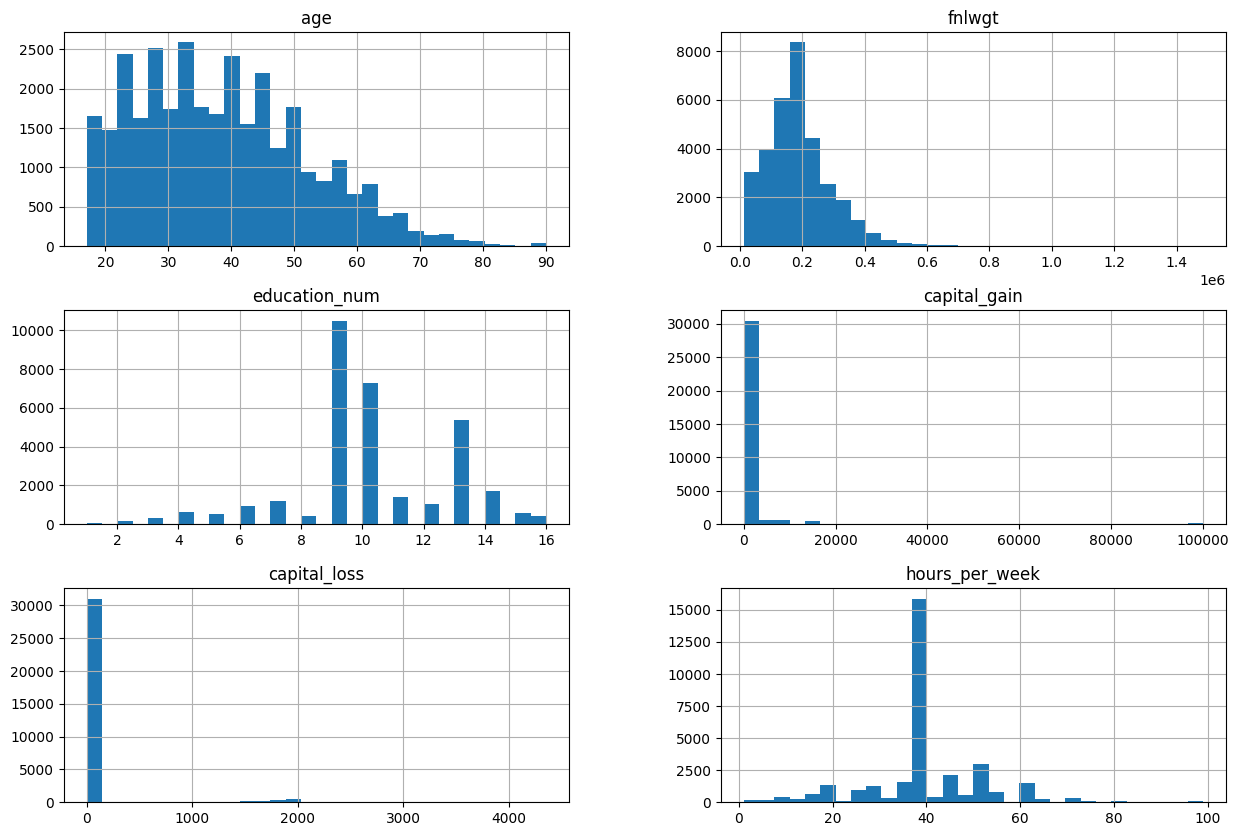

In [60]:
pandas_df = adult_df.select(["age", "fnlwgt", "education_num", "capital_gain", "capital_loss", "hours_per_week"]).toPandas()

pandas_df.hist(bins=30, figsize=(15, 10))
plt.show()

Randomly split data into training and test sets, and set seed for reproducibility.

It's best to split the data before doing any preprocessing. This allows the test dataset to more closely simulate new data when we evaluate the model.



In [61]:
trainDF, testDF = adult_df.randomSplit([0.8, 0.2], seed=42)
# TODO: display the number of records in each dataframe (trainDF, testDF)


we explore three fundamental concepts in MLlib machine learning: **Transformers**, **Estimators**, and **Pipelines**.

A **Transformer** takes a DataFrame as input and produces a new DataFrame as output. It applies predefined transformations without learning parameters. Typically, **Transformers** are used to preprocess data before training a model or making predictions with a trained MLlib model, invoked using the .transform() method.

An **Estimator** learns parameters from a DataFrame using the .fit() method and produces a Model, which itself is a **Transformer**. Unlike **Transformers**, **Estimators** derive parameters based on the input data, enabling them to adapt to specific datasets.

A Pipeline amalgamates multiple stages into a cohesive workflow that can be executed seamlessly. Constructing a machine learning model often involves configuring numerous sequential tasks. Pipelines automate this orchestration, facilitating efficient and reproducible model creation and deployment.

## Step 2: Data Preprocessing

Data preprocessing is essential to prepare the dataset for model training. This involves handling missing values, encoding categorical features, and assembling features into a format suitable for machine learning models.

In [66]:
categoricalColumns = ["workclass", "education", "marital_status", "occupation", "relationship", "race", "sex", "native_country"]

indexers = [StringIndexer(inputCol=col, outputCol=col + "_index", handleInvalid="keep") for col in categoricalColumns]

encoders = [OneHotEncoder(inputCol=col + "_index", outputCol=col + "_encoded") for col in categoricalColumns]

assemblerInputs = [col + "_encoded" for col in categoricalColumns] + ["age", "fnlwgt", "education_num", "capital_gain", "capital_loss", "hours_per_week"]
assembler = VectorAssembler(inputCols=assemblerInputs, outputCol="features")

labelIndexer = StringIndexer(inputCol="income", outputCol="income_index")

# Pipeline
pipeline = Pipeline(stages=indexers + encoders + [assembler, labelIndexer])
pipelineModel = pipeline.fit(adult_df)
preprocessedData = pipelineModel.transform(adult_df).select("features", "income_index")


In [69]:
# TODO: write an action command to run the steps



DataFrame[features: vector, income_index: double]

In [29]:
preprocessedData.first()

Row(features=SparseVector(108, {1: 1.0, 11: 1.0, 25: 1.0, 34: 1.0, 47: 1.0, 53: 1.0, 58: 1.0, 60: 1.0, 102: 50.0, 103: 83311.0, 104: 13.0, 107: 13.0}), income_index=0.0)

In [30]:
pipelineModel.transform(adult_df).show()

+----+-----------------+--------+-------------+-------------+--------------------+------------------+--------------+-------------------+-------+------------+------------+--------------+--------------+------+---------------+---------------+--------------------+----------------+------------------+----------+---------+--------------------+-----------------+-----------------+----------------------+------------------+--------------------+-------------+-------------+----------------------+--------------------+------------+
| age|        workclass|  fnlwgt|    education|education_num|      marital_status|        occupation|  relationship|               race|    sex|capital_gain|capital_loss|hours_per_week|native_country|income|workclass_index|education_index|marital_status_index|occupation_index|relationship_index|race_index|sex_index|native_country_index|workclass_encoded|education_encoded|marital_status_encoded|occupation_encoded|relationship_encoded| race_encoded|  sex_encoded|native_count

**StringIndexer**: Converts categorical columns into numerical indices. This transformation is necessary because most machine learning algorithms  require numerical input.

**VectorAssembler**: Combines indexed categorical columns and numeric columns into a single feature vector. This is the format Spark ML models expect for input features.

**Pipeline**: Combines multiple stages of transformations into a single pipeline for easier management and application to new data.
Selecting Columns: After preprocessing, we select only the features and income_index columns for model training.

## Step 3: Train-Test Split
Splitting the dataset into training and testing sets allows us to evaluate the model's performance on unseen data.

In [40]:
train_data, test_data = preprocessedData.randomSplit([0.8, 0.2], seed=12345)
print(f"Number of train data:{train_data.count()}")
print(f"Number of test data:{test_data.count()}")

Number of train data:25953
Number of test data:6607


In [39]:
train_data

DataFrame[features: vector, income_index: double]

## Step 4: Model Training and Hyperparameter Tuning
In this step, we define a Random Forest classifier, specify a parameter grid for hyperparameter tuning, and use CrossValidator to find the best combination of hyperparameters.

In [33]:
# TODO: Specify the label column and the features columns
rf = RandomForestClassifier(labelCol=, featuresCol=)
evaluator = BinaryClassificationEvaluator(labelCol="income_index", rawPredictionCol="rawPrediction", metricName="areaUnderROC")


In [34]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

param_grid = (ParamGridBuilder()
              .addGrid(rf.numTrees, [10, 20, 30])
              .addGrid(rf.maxDepth, [5, 10])
              .addGrid(rf.maxBins,[50,100])
              .build())
crossval = CrossValidator(estimator=rf,
                          estimatorParamMaps=param_grid,
                          evaluator=evaluator,
                          numFolds=3)
cvModel = crossval.fit(train_data)
bestModel = cvModel.bestModel


**RandomForestClassifier**: Initializes a Random Forest classifier with specified labelCol (target variable) and featuresCol (input features).

**ParamGridBuilder**: Defines a grid of parameters (numTrees and maxDepth in this case) to be searched during hyperparameter tuning.

**CrossValidator**: Performs k-fold cross-validation (numFolds=3 here) to find the best model configuration based on the specified evaluator (BinaryClassificationEvaluator in this case).

**Model Evaluation**: Computes the accuracy metric on the test set using the BinaryClassificationEvaluator to assess how well the model generalizes to new data.

In [75]:
predictions = bestModel.transform(train_data)
evaluator = BinaryClassificationEvaluator(labelCol="income_index", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
bestAccuracy = evaluator.evaluate(predictions)
print(f"Best Test Area Under ROC: {bestAccuracy}")
print(f"Best Param (numTrees): {bestModel.getNumTrees}")
print(f"Best Param (maxDepth): {bestModel.getMaxDepth()}")
print(f"Best Param (maxBins): {bestModel.getMaxBins()}")

Best Test Area Under ROC: 0.9208903570322906
Best Param (numTrees): 30
Best Param (maxDepth): 10
Best Param (maxBins): 100


In [76]:
# TODO: change the metric to Area under precision-recall curve


Best Test Area Under PR: 0.812782557699944
Best Param (numTrees): 30
Best Param (maxDepth): 10
Best Param (maxBins): 100


# Case Study

Work in groups (of 5 or 6) to complete a case study of your choice

The case study must incorporate either MapReduce or a machine learning pipeline on Spark

#Example: Water Quality  

Access to safe drinking water is essential for health, a basic human right, and a crucial component of effective health protection policies. Ensuring safe drinking water is an important issue for health and development at national, regional, and local levels. Research in various regions has demonstrated that investments in water supply and sanitation can yield significant economic benefits. These benefits arise from reduced adverse health effects and lowered healthcare costs, which outweigh the costs of implementing the necessary interventions.

In this exercise, we will use PySpark in developing a Random Forest model to analyze a dataset related to safe drinking water. The goal is to predict and understand the factors that contribute to safe drinking water access. This analysis will provide insights into the potential health and economic benefits of investing in water supply and sanitation infrastructure.

In [36]:
!wget -O water_potability.csv https://drive.google.com/file/d/1g39BFsY2uWpkEGIkS9A8cnwK4L70vGg7/view?usp=sharing

--2026-06-19 09:37:33--  https://drive.google.com/file/d/1g39BFsY2uWpkEGIkS9A8cnwK4L70vGg7/view?usp=sharing
Resolving drive.google.com (drive.google.com)... 74.125.142.138, 74.125.142.100, 74.125.142.102, ...
Connecting to drive.google.com (drive.google.com)|74.125.142.138|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘water_potability.csv’

water_potability.cs     [ <=>                ]  69.24K  --.-KB/s    in 0.003s  

2026-06-19 09:37:34 (25.7 MB/s) - ‘water_potability.csv’ saved [70901]



In [37]:
### [TODO]

Let's implement the following steps:
1. **Data Loading and Exploration**: Load the dataset into a PySpark DataFrame and explore its structure and contents.
2. **Data Preprocessing**: Clean and preprocess the data to make it suitable for model training. This may include handling missing values, encoding categorical features, and scaling numerical features.
3. **Model Training**: Train the Random Forest model using the prepared dataset.
4. **Model Evaluation**: Evaluate the performance of the model using appropriate metrics and validate its effectiveness in predicting safe drinking water access.
5. **Insights and Conclusions**: Analyze the results and draw conclusions about the factors influencing safe drinking water access and the potential benefits of investments in water supply and sanitation.

Let's get started!